# 🚗 Car Price Prediction Model

This notebook shows a simple beginner-friendly machine learning workflow to predict the selling price of a used car.

## 1. Project Introduction

This project uses a car dataset to train a machine learning model that predicts the selling price of a car based on important features such as present price, kilometers driven, fuel type, transmission, and age.

## 2. Import Required Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

## 3. Load Dataset

In [28]:
data_path = Path('dataset/car data.csv')
df = pd.read_csv(data_path)

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 4. Explore Dataset

In [29]:
print('Shape of the dataset:', df.shape)

df.info()

df.describe()

Shape of the dataset: (301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 5. Data Cleaning

In [30]:
print(df.isnull().sum())

df = df.drop_duplicates()
print('After removing duplicates, shape:', df.shape)

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
After removing duplicates, shape: (299, 9)


## 6. Data Preprocessing

In [31]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']

df = df.drop(columns=['Car_Name', 'Year'])

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 7. Exploratory Data Analysis (EDA)

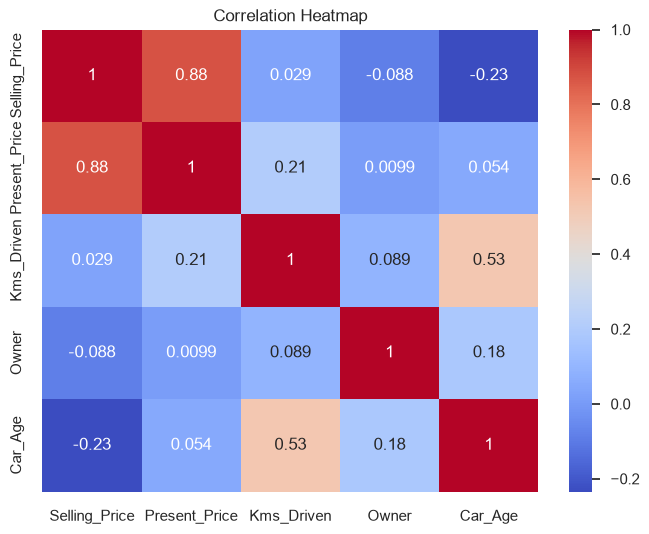

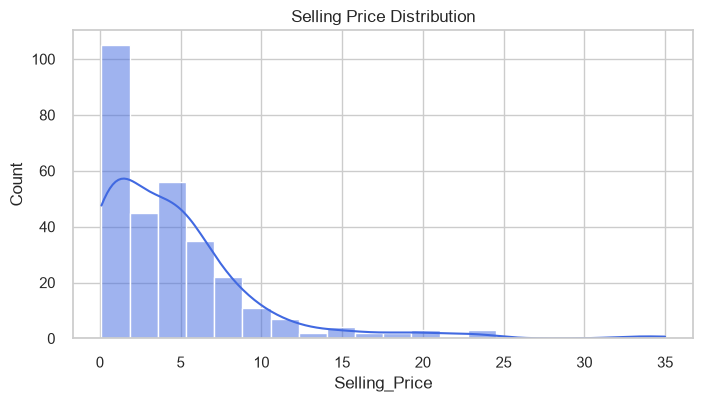

C:\Users\HP\AppData\Local\Temp\ipykernel_4936\3554960151.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fuel_Type', palette='Set2')


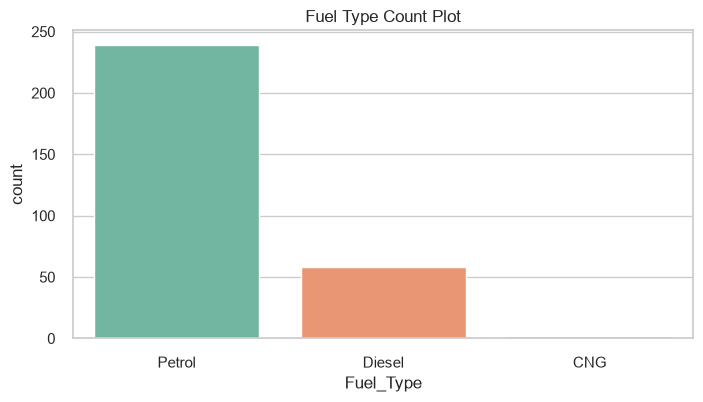

C:\Users\HP\AppData\Local\Temp\ipykernel_4936\3554960151.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Transmission', palette='viridis')


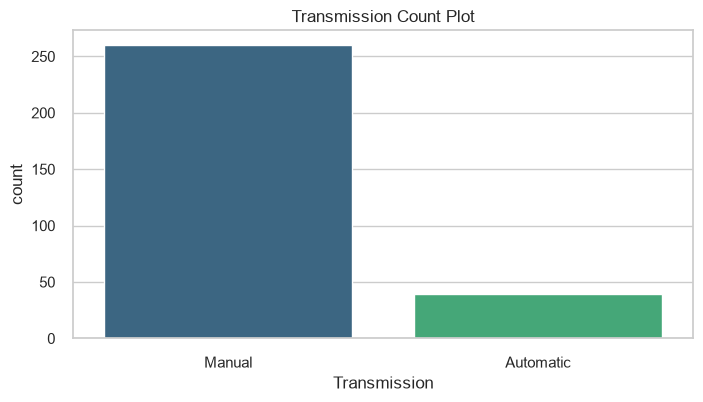

C:\Users\HP\AppData\Local\Temp\ipykernel_4936\3554960151.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette='Set2')


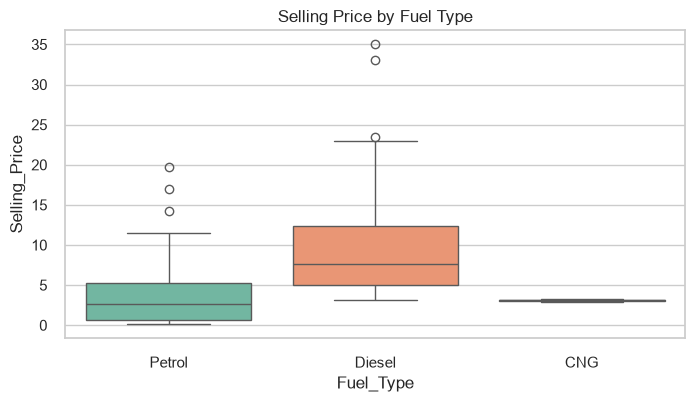

In [32]:
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['Selling_Price'], kde=True, bins=20, color='royalblue')
plt.title('Selling Price Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Fuel_Type', palette='Set2')
plt.title('Fuel Type Count Plot')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Transmission', palette='viridis')
plt.title('Transmission Count Plot')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', palette='Set2')
plt.title('Selling Price by Fuel Type')
plt.show()

## 8. Feature Selection

In [33]:
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

X.columns

Index(['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner', 'Car_Age'],
      dtype='str')

## 9. Split Dataset into Training and Testing Sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 239
Testing samples: 60


## 10. Train a Random Forest Regressor Model

In [35]:
numeric_features = ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Transmission','Owner', 'Car_Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

## 11. Predict Selling Prices

In [36]:
y_pred = model.predict(X_test)

## 12. Evaluate the Model

In [37]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Mean Absolute Error (MAE):', round(mae, 3))
print('Root Mean Squared Error (RMSE):', round(rmse, 3))
print('R² Score:', round(r2, 3))

Mean Absolute Error (MAE): 1.525
Root Mean Squared Error (RMSE): 3.695
R² Score: 0.47


## 13. Save the Trained Model

In [38]:
joblib.dump(model, 'model.pkl')
print('Model saved as model.pkl')

Model saved as model.pkl


## 14. Predict the Selling Price for a Sample Car

In [39]:
sample_car = pd.DataFrame([{
    'Present_Price': 7.50,
    'Kms_Driven': 20000,
    'Fuel_Type': 'Petrol',
    'Seller_Type': 'Dealer',
    'Transmission': 'Manual',
    'Owner': 0,
    'Car_Age': 3
}])

sample_prediction = model.predict(sample_car)[0]
print('Predicted Selling Price:', round(sample_prediction, 2), 'Lakhs')

Predicted Selling Price: 6.25 Lakhs


## 15. Visualizations for Model Performance

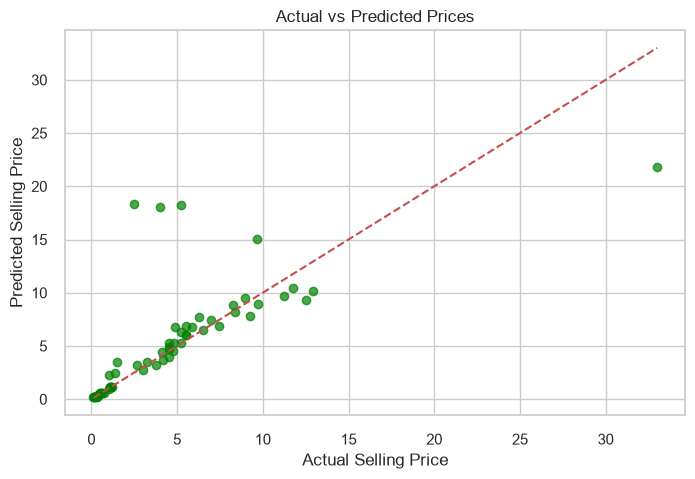

C:\Users\HP\AppData\Local\Temp\ipykernel_4936\2165724617.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')


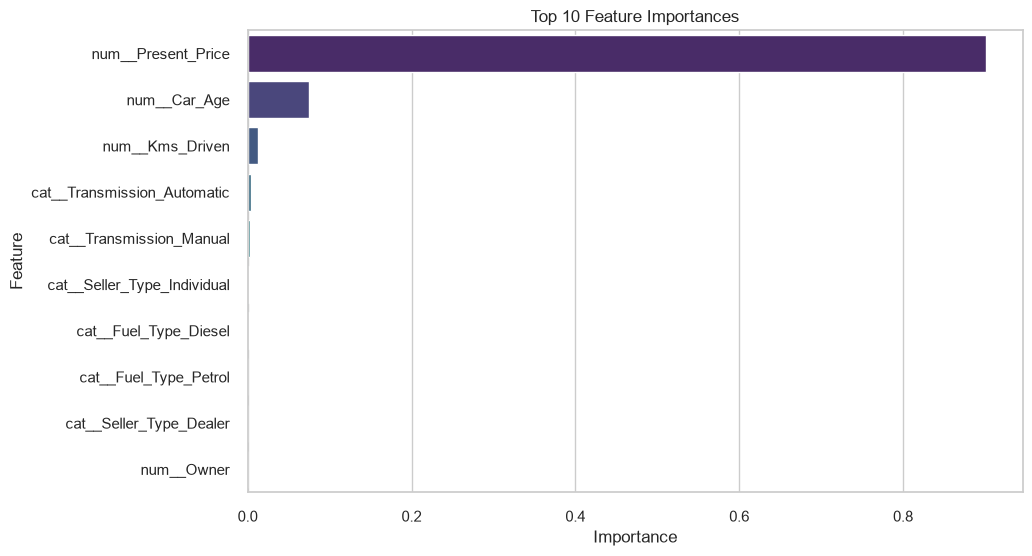

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Prices')
plt.show()

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_

feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances')
plt.show()

## 16. Conclusion

This simple machine learning project demonstrates how a beginner can build a reliable car price prediction model using basic Python libraries. The model can be improved later by adding more data and experimenting with different algorithms.